MNIST Digit Recognition using CNN

The objective of this project is to build a deep learning model that can accurately classify handwritten digits (0-9) from the MNIST dataset using a Convolutional Neural Network (CNN). Each input image is a 28x28 grayscale image, and the model must learn to recognize and distinguish digit patterns despite variations in handwriting.

The goal is to:

Automatically extract features using convolutional layers
Minimize classification error through training
Generalize well on unseen digit images (test set)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import Adam


In [ ]:
(x_train, y_train), (x_test, y_test) = mnist.load_data()

In [ ]:
x_train = x_train.reshape(-1, 28, 28, 1).astype('float32') / 255.0
x_test  = x_test.reshape(-1, 28, 28, 1).astype('float32') / 255.0

In [ ]:
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

In [ ]:
model = Sequential([
    Conv2D(32, kernel_size=(3,3), activation='relu', input_shape=(28,28,1)),
    MaxPooling2D(pool_size=(2,2)),
    Conv2D(64, kernel_size=(3,3), activation='relu'),
    MaxPooling2D(pool_size=(2,2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(10, activation='softmax')
])


In [ ]:
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history = model.fit(
    x_train, y_train,
    batch_size=128,
    epochs=12,
    validation_split=0.1,
    verbose=2
)

Epoch 1/12
422/422 - 45s - 108ms/step - accuracy: 0.9018 - loss: 0.3202 - val_accuracy: 0.9840 - val_loss: 0.0622
Epoch 2/12
422/422 - 40s - 95ms/step - accuracy: 0.9690 - loss: 0.1039 - val_accuracy: 0.9863 - val_loss: 0.0459
Epoch 3/12
422/422 - 41s - 98ms/step - accuracy: 0.9766 - loss: 0.0770 - val_accuracy: 0.9873 - val_loss: 0.0437
Epoch 4/12
422/422 - 41s - 96ms/step - accuracy: 0.9807 - loss: 0.0632 - val_accuracy: 0.9900 - val_loss: 0.0389
Epoch 5/12
422/422 - 41s - 96ms/step - accuracy: 0.9847 - loss: 0.0522 - val_accuracy: 0.9895 - val_loss: 0.0350
Epoch 6/12
422/422 - 41s - 98ms/step - accuracy: 0.9855 - loss: 0.0464 - val_accuracy: 0.9905 - val_loss: 0.0348
Epoch 7/12
422/422 - 41s - 98ms/step - accuracy: 0.9877 - loss: 0.0391 - val_accuracy: 0.9917 - val_loss: 0.0290
Epoch 8/12
422/422 - 40s - 96ms/step - accuracy: 0.9885 - loss: 0.0376 - val_accuracy: 0.9925 - val_loss: 0.0301
Epoch 9/12
422/422 - 41s - 96ms/step - accuracy: 0.9905 - loss: 0.0310 - val_accuracy: 0.9923 -

In [ ]:
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
print(f"Test accuracy: {test_acc*100:.2f}%")

Test accuracy: 99.04%


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step


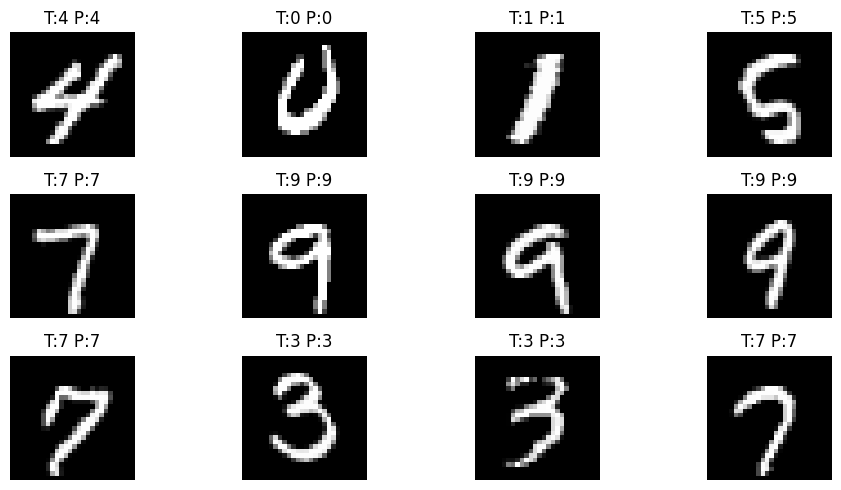

In [ ]:
idxs = np.random.choice(len(x_test), size=12, replace=False)
samples = x_test[idxs]
true_labels = np.argmax(y_test[idxs], axis=1)
pred_probs = model.predict(samples)
pred_labels = np.argmax(pred_probs, axis=1)

plt.figure(figsize=(10,5))
for i, (img, true, pred) in enumerate(zip(samples, true_labels, pred_labels)):
    plt.subplot(3,4,i+1)
    plt.imshow(img.squeeze(), cmap='gray')
    plt.title(f"T:{true} P:{pred}")
    plt.axis('off')
plt.tight_layout()
plt.show()